In [120]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, glob, math
import pandas as pd
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth
import matplotlib.ticker as mticker


plt.rcParams.update({'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 9})

# OUT_DIR        = '/oak/stanford/groups/ettore88/nberrios'
# PROCESSING_VERSION = "base"

# OUT_DIR        = '/oak/stanford/groups/ettore88/nberrios/tn01_bp2'
# PROCESSING_VERSION = "tn01_bp2"

# OUT_DIR        = '/oak/stanford/groups/ettore88/nberrios/tn1_bp2'
# PROCESSING_VERSION = "tn1_bp2"

# OUT_DIR        = '/oak/stanford/groups/ettore88/nberrios/tn5_bp2'
# PROCESSING_VERSION = "tn5_bp2"

# OUT_DIR = "/oak/stanford/groups/ettore88/nberrios/tn10_bp2"
# PROCESSING_VERSION = "tn10_bp2"




FIG_DIR = "/home/groups/ettore88/nberrios/safod_das_git/notebooks/figures"

vp             = 3200.0
vs             = 1600.0
dz_m           = 1.0
which          = 'day'   # 'day' or 'night'
CHUNK_DAYS     = 7
xlim_show      = 1    # s

CHUNK_MODE = 'calendar_strict'   # 'calendar_strict' or 'available_files'

CATALOG        = 'NCEDC'
PARKFIELD_LAT  = 35.9747
PARKFIELD_LON  = -120.5522
RADIUS_KM      = 20.0
MIN_MAG        = 1.0

MAG_BINS       = [1.0, 2.0, 3.0, 4.0,10.0]
MAG_LABELS     = ['1-2', '2-3', '3-4', '4+']
MAG_COLORS     = ['#1B3A4B', '#4F6D7A', '#A7BBC7', '#EAF2F8']



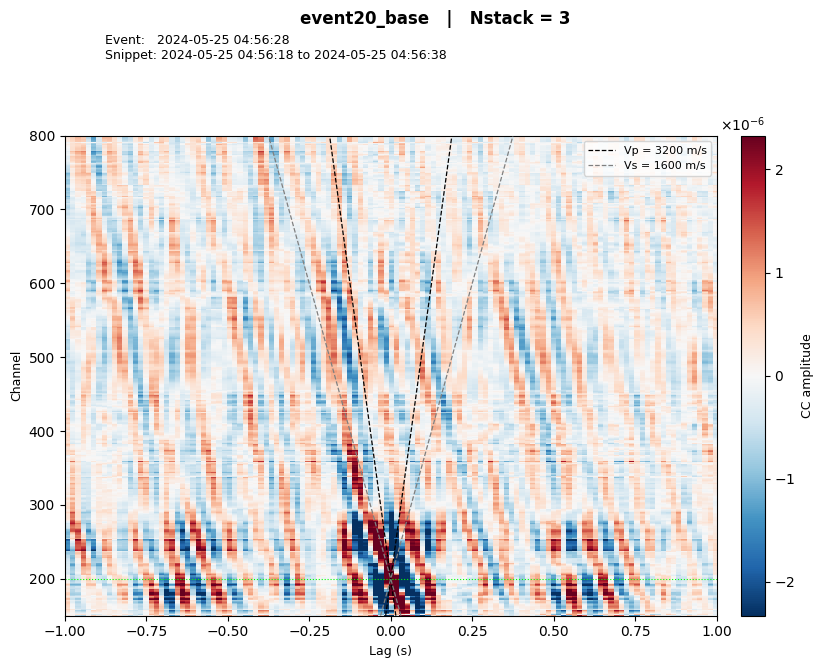

Saved /home/groups/ettore88/nberrios/safod_das_git/notebooks/figures/event20_base_EQ_20240525_045628_event20s.png


In [123]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 9})

EVENT_FILE = "/oak/stanford/groups/ettore88/nberrios/event_cc/event20_base/EQ_20240525_045628_event20s.npz"
PROCESSING_VERSION = "event20_base"
FIG_DIR = "/home/groups/ettore88/nberrios/safod_das_git/notebooks/figures"

vp = 3200.0
vs = 1600.0
dz_m = 1.0
xlim_show = 1.0

def fmt_time(s):
    s = str(s).replace("T", " ")
    s = s.replace(".150000+00:00", "")
    s = s.replace("+00:00", " UTC")
    return s

d = np.load(EVENT_FILE, allow_pickle=True)

cc = d["cc_combo"]
dt = float(d["dt"])
max_lag = float(d["max_lag"])
ch_start = int(d["ch_start"])
ch_end = int(d["ch_end"])
src = int(d["src"])
nstack = int(d["nstack_combo"])

channels = np.arange(ch_start, ch_end)
lags = np.linspace(-max_lag, max_lag, cc.shape[1])
dist = np.abs(channels - src) * dz_m

event_time = str(d["event_time"]) if "event_time" in d.files else "unknown"
snippet_start = str(d["snippet_start"]) if "snippet_start" in d.files else "unknown"
snippet_end = str(d["snippet_end"]) if "snippet_end" in d.files else "unknown"

mask = np.abs(channels - src) > 10
vsrc = np.abs(cc[mask]) if np.any(mask) else np.abs(cc)

vlim = np.percentile(vsrc, 99) if vsrc.size else 1.0
if vlim == 0:
    vlim = 1.0

fig, ax = plt.subplots(figsize=(8.8, 6.8))

im = ax.imshow(
    cc,
    extent=[lags[0], lags[-1], ch_start, ch_end],
    origin="lower",
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vlim,
    vmax=vlim,
    interpolation="nearest",
)

ax.plot(+dist/vp, channels, '--', color='k', lw=0.9, zorder=5, label=f'Vp = {vp:.0f} m/s')
ax.plot(-dist/vp, channels, '--', color='k', lw=0.9, zorder=5)
ax.plot(+dist/vs, channels, '--', color='gray', lw=0.9, zorder=5, label=f'Vs = {vs:.0f} m/s')
ax.plot(-dist/vs, channels, '--', color='gray', lw=0.9, zorder=5)

ax.axhline(src, color='lime', lw=0.8, ls=':')
ax.set_xlim(-xlim_show, xlim_show)
ax.set_xlabel("Lag (s)")
ax.set_ylabel("Channel")
ax.legend(loc="upper right", fontsize=8, frameon=True, borderpad=0.4, handlelength=2.4)

fig.suptitle(
    f"{PROCESSING_VERSION}   |   Nstack = {nstack}",
    y=0.975,
    fontsize=12,
    fontweight="semibold",
)

fig.text(
    0.125,
    0.94,
    f"Event:   {fmt_time(event_time)}\n"
    f"Snippet: {fmt_time(snippet_start)} to {fmt_time(snippet_end)}",
    ha="left",
    va="top",
    fontsize=9,
)

cbar = fig.colorbar(im, ax=ax, pad=0.03)
cbar.set_label("CC amplitude")

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
cbar.formatter = formatter
cbar.update_ticks()

os.makedirs(FIG_DIR, exist_ok=True)

out_png = os.path.join(
    FIG_DIR,
    f"{PROCESSING_VERSION}_EQ_20240525_045628_event20s.png",
)

fig.tight_layout(rect=[0, 0, 1, 0.89])
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {out_png}")

## Build 7-day stacks

In [122]:
all_files = sorted(glob.glob(os.path.join(OUT_DIR, f'*_{which}.npz')))
print(f'Found {len(all_files)} {which} files')
print(f'  First: {os.path.basename(all_files[0])}')
print(f'  Last:  {os.path.basename(all_files[-1])}')

file_df = pd.DataFrame({
    'path': all_files,
    'date': [
        pd.Timestamp(os.path.basename(f).replace(f'_{which}.npz', ''), tz='UTC')
        for f in all_files
    ],
}).sort_values('date').reset_index(drop=True)

chunks = []
if CHUNK_MODE == 'calendar_strict':
    file_map = dict(zip(file_df['date'], file_df['path']))
    week_starts = pd.date_range(
        file_df['date'].min(),
        file_df['date'].max(),
        freq=f'{CHUNK_DAYS}D',
    )

    for week_start in week_starts:
        week_dates = pd.date_range(week_start, periods=CHUNK_DAYS, freq='1D', tz='UTC')
        week_files = [file_map.get(d) for d in week_dates]
        missing_dates = [d.strftime('%Y-%m-%d') for d, f in zip(week_dates, week_files) if f is None]

        if missing_dates:
            print(
                f"Skipping {week_start.strftime('%Y-%m-%d')} — "
                f"{week_dates[-1].strftime('%Y-%m-%d')} "
                f"(missing {len(missing_dates)} day(s): {', '.join(missing_dates)})"
            )
            continue

        chunks.append({
            'week_start': week_start,
            'week_end': week_dates[-1],
            'files': week_files,
            'expected_dates': week_dates,
            'missing_dates': missing_dates,
            'mode': CHUNK_MODE,
        })

    print(f'{len(chunks)} strict calendar {CHUNK_DAYS}-day chunk(s) kept')

elif CHUNK_MODE == 'available_files':
    file_chunks = [
        file_df.iloc[i:i+CHUNK_DAYS].copy()
        for i in range(0, len(file_df), CHUNK_DAYS)
    ]
    if len(file_chunks[-1]) < CHUNK_DAYS:
        print(f'Dropping incomplete last available-files chunk ({len(file_chunks[-1])} days)')
        file_chunks = file_chunks[:-1]

    for chunk_df in file_chunks:
        files = chunk_df['path'].tolist()
        dates = chunk_df['date'].tolist()
        expected_dates = pd.date_range(dates[0], periods=CHUNK_DAYS, freq='1D', tz='UTC')
        missing_dates = [
            d.strftime('%Y-%m-%d')
            for d in expected_dates
            if d not in set(dates)
        ]

        chunks.append({
            'week_start': dates[0],
            'week_end': dates[-1],
            'files': files,
            'expected_dates': expected_dates,
            'missing_dates': missing_dates,
            'mode': CHUNK_MODE,
        })

    print(f'{len(chunks)} available-files {CHUNK_DAYS}-file chunk(s) kept')

else:
    raise ValueError("CHUNK_MODE must be 'calendar_strict' or 'available_files'")

used_files = []
for chunk in chunks:
    for f in chunk['files']:
        d = np.load(f, allow_pickle=True)
        cc = d['cc_combo']
        nd = int(d['nstack_combo'])
        if cc.ndim == 2 and cc.shape[1] > 0 and nd > 0:
            used_files.append(f)
        else:
            print(f"Skipping invalid file: {os.path.basename(f)} shape={cc.shape} nstack={nd}")

used_files = sorted(set(used_files))
if len(used_files) == 0:
    raise ValueError(f"No valid {which} files found after filtering.")

min_nlag = min(
    np.load(f, allow_pickle=True)['cc_combo'].shape[1]
    for f in used_files
)

meta     = np.load(used_files[0], allow_pickle=True)
dt       = float(meta['dt'])
max_lag  = float(meta['max_lag'])
ch_start = int(meta['ch_start'])
ch_end   = int(meta['ch_end'])
src      = int(meta['src'])
channels = np.arange(ch_start, ch_end)
lags     = np.linspace(-max_lag, max_lag, min_nlag)
dist     = np.abs(channels - src) * dz_m

stacks = []
for chunk in chunks:
    cc_sum = np.zeros((ch_end - ch_start, min_nlag))
    nstack = 0
    used_in_chunk = 0

    for f in chunk['files']:
        d = np.load(f, allow_pickle=True)
        cc = d['cc_combo']
        nd = int(d['nstack_combo'])

        if cc.ndim != 2 or cc.shape[1] == 0 or nd == 0:
            print(f"Skipping invalid file in stack: {os.path.basename(f)} shape={cc.shape} nstack={nd}")
            continue

        cc_sum += cc[:, :min_nlag] * nd
        nstack += nd
        used_in_chunk += 1

    if nstack == 0:
        print(
            f"Skipping chunk {chunk['week_start'].strftime('%Y-%m-%d')} — "
            f"{chunk['week_end'].strftime('%Y-%m-%d')} (no valid stacks)"
        )
        continue

    cc_mean = cc_sum / nstack
    d0 = chunk['week_start'].strftime('%Y-%m-%d')
    d1 = chunk['week_end'].strftime('%Y-%m-%d')
    t0 = chunk['week_start']
    t1 = chunk['week_end'] + pd.Timedelta(days=1)

    stacks.append({
        'label': f'{d0}\n{d1}',
        'date_start': d0,
        'date_end': d1,
        'start_utc': t0,
        'end_utc': t1,
        'nstack': nstack,
        'nfiles_present': used_in_chunk,
        'missing_dates': chunk['missing_dates'],
        'chunk_mode': chunk['mode'],
        'cc': cc_mean,
    })
    print(
        f"  {d0} — {d1}: nstack={nstack}, "
        f"nfiles={used_in_chunk}/{CHUNK_DAYS}, "
        f"missing={len(chunk['missing_dates'])}"
    )

if len(stacks) == 0:
    raise ValueError(f"No valid {which} stacks were built.")

query_start = min(s['start_utc'] for s in stacks)
query_end   = max(s['end_utc'] for s in stacks)
print(f'Event query window: {query_start} to {query_end}')

client = Client(CATALOG)
catalog = client.get_events(
    starttime=query_start.to_pydatetime(),
    endtime=query_end.to_pydatetime(),
    minmagnitude=MIN_MAG,
    latitude=PARKFIELD_LAT,
    longitude=PARKFIELD_LON,
    maxradius=RADIUS_KM / 111.32,
    includearrivals=False,
)

rows = []
for event in catalog:
    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]
    distance_m, _, _ = gps2dist_azimuth(
        PARKFIELD_LAT,
        PARKFIELD_LON,
        origin.latitude,
        origin.longitude,
    )
    rows.append({
        'time_utc': pd.Timestamp(origin.time.datetime, tz='UTC'),
        'latitude': origin.latitude,
        'longitude': origin.longitude,
        'depth_km': np.nan if origin.depth is None else origin.depth / 1000.0,
        'magnitude': magnitude.mag,
        'magnitude_type': magnitude.magnitude_type,
        'distance_km': distance_m / 1000.0,
    })

events_df = pd.DataFrame(rows)
if len(events_df) == 0:
    events_df = pd.DataFrame(columns=['time_utc', 'latitude', 'longitude', 'depth_km', 'magnitude', 'magnitude_type', 'distance_km'])
else:
    events_df = events_df.sort_values('time_utc').reset_index(drop=True)
    events_df = events_df[events_df['distance_km'] <= RADIUS_KM].reset_index(drop=True)

for s in stacks:
    mask = (events_df['time_utc'] >= s['start_utc']) & (events_df['time_utc'] < s['end_utc'])
    s['events'] = events_df.loc[mask].copy()
    s['nevents'] = len(s['events'])

print(f'Total events in catalog selection: {len(events_df)}')
print('Events per stack:')
for s in stacks:
    print(f"  {s['date_start']} — {s['date_end']}: nevents={s['nevents']}")


Found 0 day files


IndexError: list index out of range

## Plot 7-day stacks with seismicity


In [ ]:
mask = np.abs(channels - src) > 10

# out_dir = os.path.join(OUT_DIR, f'weekly_stacks_seismicity_{which}')
# out_dir = os.path.join(OUT_DIR, f'weekly_stacks_seismicity_{PROCESSING_VERSION}_{which}')
out_dir = os.path.join(FIG_DIR, f'weekly_stacks_seismicity_{PROCESSING_VERSION}_{which}')
os.makedirs(out_dir, exist_ok=True)

for stack in stacks:
    fig, (ax_cc, ax_eq) = plt.subplots(
        2, 1,
        figsize=(7.5, 8.5),
        constrained_layout=True,
        gridspec_kw={'height_ratios': [4, 1.6]},
    )

    cc = stack['cc']
    vsrc = np.abs(cc[mask]) if np.any(mask) else np.abs(cc)

    vlim = np.percentile(vsrc, 99) if vsrc.size else 1.0
    if vlim == 0:
        vlim = 1.0

    im = ax_cc.imshow(
        cc,
        extent=[lags[0], lags[-1], ch_start, ch_end],
        origin='lower',
        aspect='auto',
        cmap='RdBu_r',
        vmin=-vlim,
        vmax=vlim,
        interpolation='nearest',
    )

    ax_cc.plot(+dist/vp, channels, '--', color='k', lw=0.8, zorder=5)
    ax_cc.plot(-dist/vp, channels, '--', color='k', lw=0.8, zorder=5)
    ax_cc.plot(+dist/vs, channels, '--', color='gray', lw=0.8, zorder=5)
    ax_cc.plot(-dist/vs, channels, '--', color='gray', lw=0.8, zorder=5)

    ax_cc.axhline(src, color='lime', lw=0.8, ls=':')
    ax_cc.set_xlim(-xlim_show, xlim_show)
    ax_cc.set_xlabel('Lag (s)')
    ax_cc.set_ylabel('Channel')

    ax_cc.set_title(
        f"{stack['date_start']} to {stack['date_end']}\n"
        f"{PROCESSING_VERSION} | Nstack={stack.get('nstack', 0)}, "
        f"Nevents={stack.get('nevents', 0)}",
        fontsize=10,
    )

    cbar = fig.colorbar(im, ax=ax_cc, pad=0.02)
    cbar.set_label('CC amplitude')

    events = stack.get('events')
    if events is None:
        events = pd.DataFrame(columns=['time_utc', 'magnitude'])
    else:
        events = events.copy()

    day_edges = pd.date_range(stack['start_utc'], stack['end_utc'], freq='1D')
    day_centers = day_edges[:-1] + pd.Timedelta(hours=12)

    counts = pd.DataFrame(
        0,
        index=day_centers,
        columns=MAG_LABELS,
        dtype=float,
    )

    if len(events):
        events['mag_bin'] = pd.cut(
            events['magnitude'],
            bins=MAG_BINS,
            labels=MAG_LABELS,
            right=False,
            include_lowest=True,
        )

        events['day'] = events['time_utc'].dt.floor('D') + pd.Timedelta(hours=12)

        grouped = (
            events.groupby(['day', 'mag_bin'], observed=False)
            .size()
            .unstack(fill_value=0)
        )

        grouped = grouped.reindex(
            index=day_centers,
            columns=MAG_LABELS,
            fill_value=0,
        )

        counts.loc[:, :] = grouped.to_numpy()

    x = mdates.date2num(counts.index.tz_localize(None).to_pydatetime())
    bottom = np.zeros(len(counts))

    for label, color in zip(MAG_LABELS, MAG_COLORS):
        vals = counts[label].to_numpy()

        ax_eq.bar(
            x,
            vals,
            bottom=bottom,
            width=0.8,
            color=color,
            edgecolor='black',
            linewidth=0.3,
            align='center',
            label=label,
        )

        bottom += vals

    ax_eq.set_xlim(
        mdates.date2num(stack['start_utc'].tz_localize(None).to_pydatetime()),
        mdates.date2num(
            (stack['end_utc'] - pd.Timedelta(seconds=1))
            .tz_localize(None)
            .to_pydatetime()
        ),
    )

    ax_eq.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax_eq.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_eq.tick_params(axis='x', rotation=45)

    ax_eq.set_ylabel('Event count')
    ax_eq.set_xlabel('Date (UTC)')

    ymax = int(counts.sum(axis=1).max()) if len(counts) else 0
    ax_eq.set_ylim(0, max(4, ymax))
    ax_eq.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax_eq.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
    ax_eq.legend(title='Magnitude', loc='upper right', frameon=True)

    out_png = os.path.join(
        out_dir,
        f"weekly_stack_{PROCESSING_VERSION}_{which}_"
        f"{stack['date_start']}_to_{stack['date_end']}.png",
    )

    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Saved {out_png}')

In [ ]:
events_df[events_df['time_utc'].dt.strftime('%Y-%m-%d') == '2024-05-25'][
  ['time_utc', 'magnitude', 'distance_km']
]


In [ ]:
pwd

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VERSIONS = [
    ("base", "/oak/stanford/groups/ettore88/nberrios"),
    ("tn10_bp2", "/oak/stanford/groups/ettore88/nberrios/tn10_bp2"),
    ("tn5_bp2", "/oak/stanford/groups/ettore88/nberrios/tn5_bp2"),
    ("tn1_bp2", "/oak/stanford/groups/ettore88/nberrios/tn1_bp2"),
    ("tn01_bp2", "/oak/stanford/groups/ettore88/nberrios/tn01_bp2"),
]

WHICH = "day"          # "day" or "night"
START_DATE = "2024-05-21"
CHUNK_DAYS = 7
XLIM_SHOW = 1.0

def load_week_stack(out_dir, start_date, which, chunk_days=7):
    dates = pd.date_range(pd.Timestamp(start_date, tz="UTC"), periods=chunk_days, freq="1D")
    files = [os.path.join(out_dir, f"{d.strftime('%Y-%m-%d')}_{which}.npz") for d in dates]

    missing = [f for f in files if not os.path.exists(f)]
    if missing:
        raise FileNotFoundError(f"Missing files for {out_dir}: {missing}")

    valid = []
    for f in files:
        d = np.load(f, allow_pickle=True)
        cc = d["cc_combo"]
        nd = int(d["nstack_combo"])

        if cc.ndim == 2 and cc.shape[1] > 0 and nd > 0:
            valid.append((f, d, cc, nd))
        else:
            print(f"Skipping invalid file: {f} shape={cc.shape} nstack={nd}")

    if not valid:
        raise ValueError(f"No valid files in {out_dir} for {start_date}")

    min_nlag = min(cc.shape[1] for _, _, cc, _ in valid)

    meta = valid[0][1]
    dt = float(meta["dt"])
    max_lag = float(meta["max_lag"])
    ch_start = int(meta["ch_start"])
    ch_end = int(meta["ch_end"])
    src = int(meta["src"])

    cc_sum = np.zeros((ch_end - ch_start, min_nlag))
    nstack = 0

    for _, _, cc, nd in valid:
        cc_sum += cc[:, :min_nlag] * nd
        nstack += nd

    cc_mean = cc_sum / nstack
    lags = np.linspace(-max_lag, max_lag, min_nlag)

    return {
        "cc": cc_mean,
        "nstack": nstack,
        "dt": dt,
        "max_lag": max_lag,
        "ch_start": ch_start,
        "ch_end": ch_end,
        "src": src,
        "lags": lags,
    }

results = []

for version, out_dir in VERSIONS:
    res = load_week_stack(out_dir, START_DATE, WHICH, CHUNK_DAYS)
    results.append((version, res))
    print(version, "nstack =", res["nstack"], "shape =", res["cc"].shape)

ref = results[0][1]

channels = np.arange(ref["ch_start"], ref["ch_end"])
mask = np.abs(channels - ref["src"]) > 10

amp_source = np.concatenate([
    np.abs(r["cc"][mask]).ravel() if np.any(mask) else np.abs(r["cc"]).ravel()
    for _, r in results
])

vlim = np.percentile(amp_source, 99)
if vlim == 0:
    vlim = 1.0

diffs = []

for version, r in results[1:]:
    diffs.append((f"{version} - base", r["cc"] - ref["cc"]))

dsrc = np.concatenate([np.abs(d).ravel() for _, d in diffs])

dlim = np.percentile(dsrc, 99)
if dlim == 0:
    dlim = 1.0

fig, axes = plt.subplots(2, 5, figsize=(22, 9), constrained_layout=True)

for ax, (version, r) in zip(axes[0], results):
    im = ax.imshow(
        r["cc"],
        extent=[r["lags"][0], r["lags"][-1], r["ch_start"], r["ch_end"]],
        origin="lower",
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vlim,
        vmax=vlim,
        interpolation="nearest",
    )

    ax.axhline(r["src"], color="lime", lw=0.8, ls=":")
    ax.set_xlim(-XLIM_SHOW, XLIM_SHOW)
    ax.set_title(f"{version}\nNstack={r['nstack']}")
    ax.set_xlabel("Lag (s)")
    ax.set_ylabel("Channel")

fig.colorbar(im, ax=axes[0], label="CC amplitude", shrink=0.9)

for ax, (title, diff) in zip(axes[1, :4], diffs):
    imd = ax.imshow(
        diff,
        extent=[ref["lags"][0], ref["lags"][-1], ref["ch_start"], ref["ch_end"]],
        origin="lower",
        aspect="auto",
        cmap="RdBu_r",
        vmin=-dlim,
        vmax=dlim,
        interpolation="nearest",
    )

    ax.axhline(ref["src"], color="lime", lw=0.8, ls=":")
    ax.set_xlim(-XLIM_SHOW, XLIM_SHOW)
    ax.set_title(title)
    ax.set_xlabel("Lag (s)")
    ax.set_ylabel("Channel")

axes[1, 4].axis("off")

fig.colorbar(imd, ax=axes[1, :4], label="Difference from base", shrink=0.9)

fig.suptitle(
    f"{START_DATE} to "
    f"{(pd.Timestamp(START_DATE) + pd.Timedelta(days=CHUNK_DAYS-1)).strftime('%Y-%m-%d')} — {WHICH}",
    fontsize=14,
)

plt.show()